In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import astropy.visualization.hist
from sklearn.neighbors import KernelDensity

import numpy as np
import pylab as plt
import scipy.stats
from tqdm.notebook import tqdm

## Irreducible Mass

In [2]:
def f(chi):
    return np.sqrt((1+np.sqrt(1-chi**2))/2)

def M_irre(M,chi):
    return M*f(chi)

def integrand(f,x):
    return ((2/np.pi)**0.5 / sigma ) * np.exp(-(x/f -1)**2 /(2*sigma**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f

def p_f(f):
    return 2*(2*f**2-1)/np.sqrt(1-f**2)

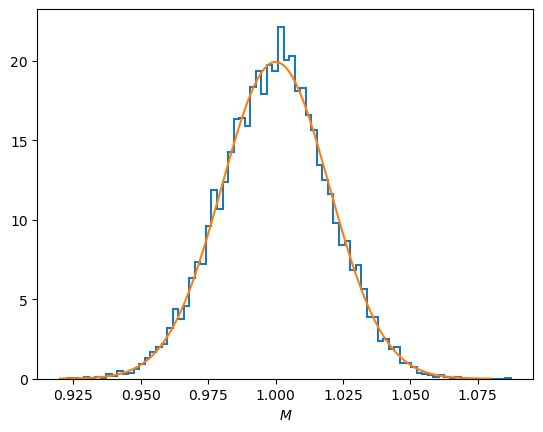

In [3]:
mu=1
sigma=0.02
N=10000

np.random.seed(3)

chi=np.random.uniform(0,1,N)
M=scipy.stats.norm(loc=mu, scale=sigma).rvs(N)
x=np.linspace(mu-4*sigma,mu+4*sigma,N)
plt.hist(M,density=True,histtype='step',bins=80,lw=1.5);
plt.plot(x,scipy.stats.norm.pdf(x, 1, sigma))

plt.xlabel(r'$M$');

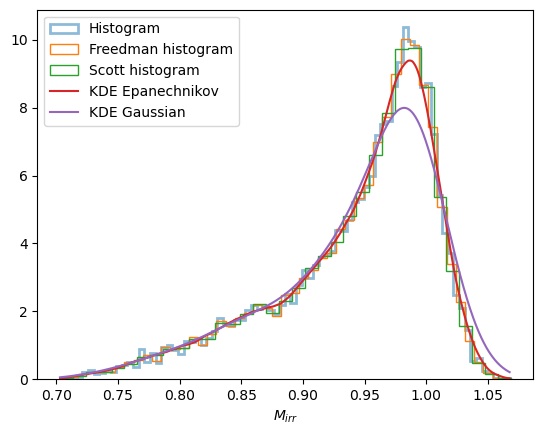

In [4]:
M_irr=M_irre(M,chi)
plt.hist(M_irr,density=True,histtype='step',bins=80,lw=2, alpha=0.5, label='Histogram');
astropy.visualization.hist(M_irr, bins="freedman", histtype="step",density=True, label='Freedman histogram');
astropy.visualization.hist(M_irr, bins="scott", histtype="step",density=True, label='Scott histogram');

xgrid = np.linspace(M_irr.min(),M_irr.max(),1000)

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis])
    return np.exp(log_pdf)

PDFepanechnikov = kde_sklearn(M_irr,bandwidth=0.02,kernel="epanechnikov") 
PDFgaussian = kde_sklearn(M_irr,bandwidth=0.02,kernel="gaussian") 
plt.plot(xgrid,PDFepanechnikov, label='KDE Epanechnikov') 
plt.plot(xgrid,PDFgaussian, label='KDE Gaussian') 
plt.legend(loc='upper left');
plt.xlabel(r'$M_{irr}$');

## Kolmogorov Smirnov Test

In [5]:
sigma=np.logspace(-5,5,20)
KSM=np.array([])
KSf=np.array([])

chi = np.random.uniform(0,1,N)
for i in range(len(sigma)):

    M=np.random.normal(loc=mu,scale=sigma[i],size=N)

    KSM=np.append(KSM,scipy.stats.ks_2samp(M, M_irre(M,chi))[0])
    KSf=np.append(KSf,scipy.stats.ks_2samp(f(chi), M_irre(M,chi))[0])

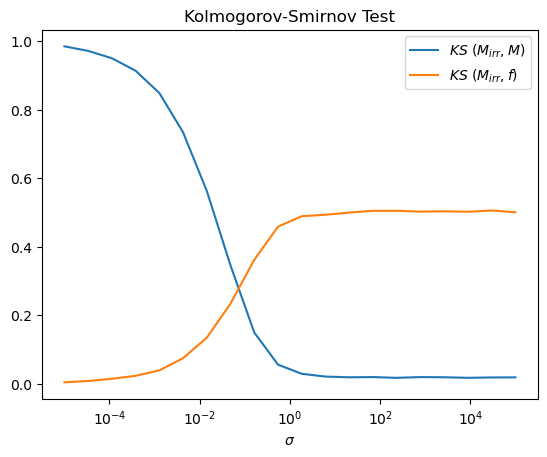

In [6]:
plt.plot(sigma,KSM,label=r"$KS \ (M_{irr}, M)$")
plt.plot(sigma,KSf,label=r"$KS \ (M_{irr}, f)$")

plt.xlabel(r'$\sigma$')
plt.title('Kolmogorov-Smirnov Test')

plt.semilogx()
plt.legend(loc='upper right');

For small $\sigma$, $M_{irr}$ goes to $f$. \
For big $\sigma$, $M_{irr}$ goes to $M$.

## KDE accordance with different bandwidths

In [7]:
N=10000
sigma=0.02

M=np.random.normal(loc=1,scale=sigma,size=N)
chi=np.random.uniform(0,1,N)
M_irr=M_irre(M,chi)

x=np.linspace(min(1-5*sigma,1/np.sqrt(2)),1+5*sigma,N)

Mirr=[scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in x]

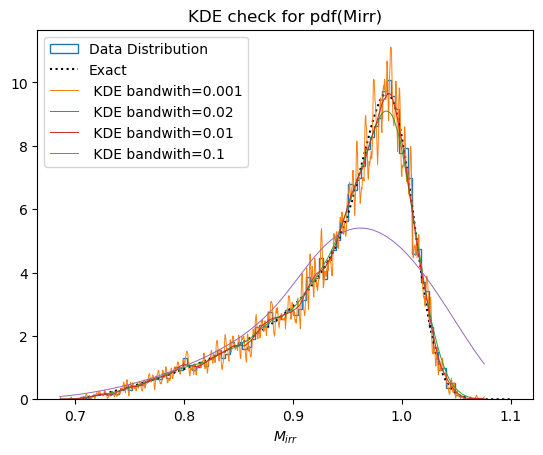

In [8]:
plt.hist(M_irr,bins=100, density=True, histtype='step',lw=1, label='Data Distribution');
plt.plot(x,Mirr,label='Exact',c='black',ls='dotted')
xgrid=np.linspace(M_irr.min(),M_irr.max(),1000)

for bandwidth in [0.001,0.02,0.01,0.1]:
    kdepdf=kde_sklearn(M_irr,bandwidth=bandwidth,kernel="epanechnikov") 
    plt.plot(xgrid,kdepdf,label=' KDE bandwith='+str(bandwidth),lw=0.7)

plt.xlabel(r'$M_{irr}$')
plt.title('KDE check for pdf(Mirr)')
plt.legend(loc='best');

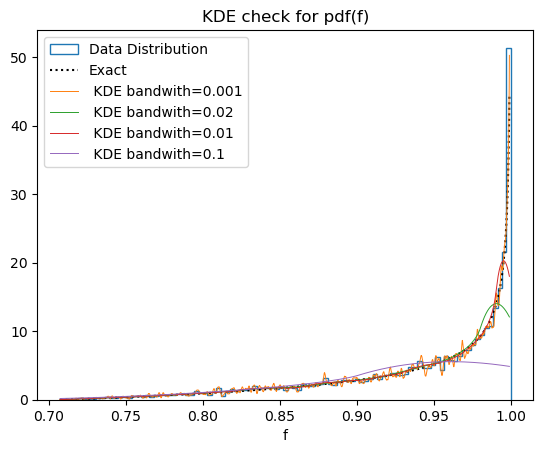

In [9]:
chi=np.random.uniform(0,1,N)[:-1]
plt.hist(f(chi),bins=100, density=True, histtype='step',lw=1, label='Data Distribution');
xgrid=np.linspace(1/np.sqrt(2),1.0-1e-3,N-1)
plt.plot(xgrid,p_f(xgrid),label='Exact',c='black',ls='dotted')

for bandwidth in [0.001,0.02,0.01,0.1]:
    kdepdf = kde_sklearn(f(chi),bandwidth=bandwidth,kernel="epanechnikov") 
    plt.plot(xgrid,kdepdf,label=' KDE bandwith='+str(bandwidth),lw=0.7)

plt.xlabel('f')
plt.title('KDE check for pdf(f)')
plt.legend(loc='best');